In [13]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import proj3d

In [14]:
DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
boundary_dataset = xr.load_dataset(DIR+'/dataset/250610-extrap_expand_dataset.nc')

In [15]:
xyz = boundary_dataset.composition.values.T[:,[0,2,1]]
ell = boundary_dataset.labels.values

In [16]:
from sklearn.neighbors import KDTree
from collections import defaultdict

def find_boundary_points(points, labels, k=10):
    """
    Identify boundary points in a point cloud with labels using KDTree.
    
    Parameters
    ----------
    points : ndarray of shape (N, 3)
        3D coordinates of points
    labels : ndarray of shape (N,)
        Class labels (e.g. +1/-1 or multiclass)
    k : int
        Number of neighbors to check for label differences
    
    Returns
    -------
    boundaries : dict
        Dictionary where keys are (label_a, label_b) tuples and values 
        are arrays of boundary points lying between those classes.
    """
    tree = KDTree(points)
    boundaries = defaultdict(list)

    for i, p in enumerate(points):
        _, idx = tree.query([p], k=k)
        neighbor_labels = labels[idx[0]]
        
        # Compare with current point’s label
        current_label = labels[i]
        diff_labels = set(neighbor_labels) - {current_label}
        
        for other_label in diff_labels:
            key = tuple(sorted((current_label.item(), other_label.item())))
            boundaries[key].append(p)

    # Convert lists to numpy arrays
    return {k: np.array(v) for k, v in boundaries.items()}

boundaries = find_boundary_points(xyz, ell, k=16)

for key, val in boundaries.items():
    print(f"Boundary {key}: {len(val)} points")

Boundary (0, 1): 2722 points
Boundary (1, 2): 1809 points


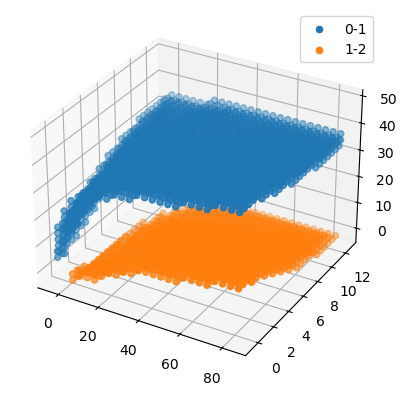

In [17]:
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
for key, points in boundaries.items():
    ax.scatter(
        points[:,0],
        points[:,1],
        points[:,2],
        label = "-".join(f"{k}" for k in key)
    )
ax.legend()
plt.show()

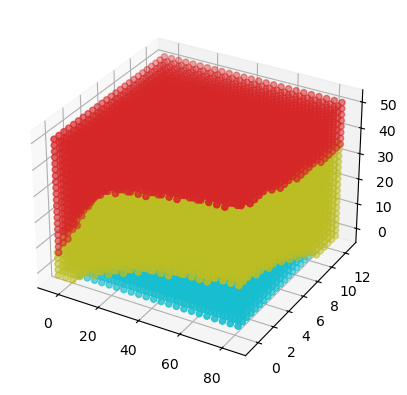

In [18]:
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
phase_colors =['tab:red','tab:olive','tab:cyan']
for label in np.unique(ell):
    mask = ell==label
    ax.scatter(
        xyz[mask,0],
        xyz[mask,1],
        xyz[mask,2],
        color = phase_colors[label]
    )

In [19]:
import torch
import torch.optim as optim
import numpy as np

import matplotlib.pyplot as plt

from funcshape.surface import Surface
from funcshape.transforms import SRNF
from funcshape.visual import (
    get_common_colornorm,
    plot_surface,
    plot_diffeomorphism_2d,
)
    
from funcshape.networks import SurfaceReparametrizer
from funcshape.layers.sinefourier import SineFourierLayer
from funcshape.loss import SurfaceDistance
from funcshape.reparametrize import reparametrize
from funcshape.logging import Logger

In [20]:
from scipy.interpolate import RBFInterpolator
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from scipy.interpolate import griddata

class PointCloudSurface(Surface):
    def __init__(self, points, uv=None, method="nearest", normalize=False):
        """
        points: array of shape (N, 3) -> the point cloud in 3D
        uv: array of shape (N, 2) -> optional parameterization for each point
            If None, a default 2D projection (PCA) is used.
        method: interpolation method ('linear', 'nearest', 'cubic')
        normalize : bool, default=True
            If True, normalize the 3D points to lie in [0,1]^3.
        """
        self.points = np.asarray(points)
        self.method = method

        # Normalize 3D coordinates if requested
        if normalize:
            min_vals = points.min(axis=0)
            max_vals = points.max(axis=0)
            ranges = np.where(max_vals > min_vals, max_vals - min_vals, 1.0)
            points = (points - min_vals) / ranges
        self.points = points

        if uv is None:
            # Project to 2D with PCA
            uv = PCA(n_components=2).fit_transform(self.points)
            # Normalize to [0,1]^2
            uv = (uv - uv.min(0)) / (uv.max(0) - uv.min(0))
        self.uv = np.asarray(uv)

        # Build interpolation functions for each coordinate
        self._interp_x = lambda uv: griddata(self.uv, self.points[:,0], uv, method=self.method)
        self._interp_y = lambda uv: griddata(self.uv, self.points[:,1], uv, method=self.method)
        self._interp_z = lambda uv: griddata(self.uv, self.points[:,2], uv, method=self.method)

        # Pass callable mapping into Surface base class
        super().__init__(
            (
                lambda x: torch.tensor(self._interp_x(x.detach().cpu().numpy()), dtype=torch.float32),
                lambda x: torch.tensor(self._interp_y(x.detach().cpu().numpy()), dtype=torch.float32),
                lambda x: torch.tensor(self._interp_z(x.detach().cpu().numpy()), dtype=torch.float32),
            )
        )

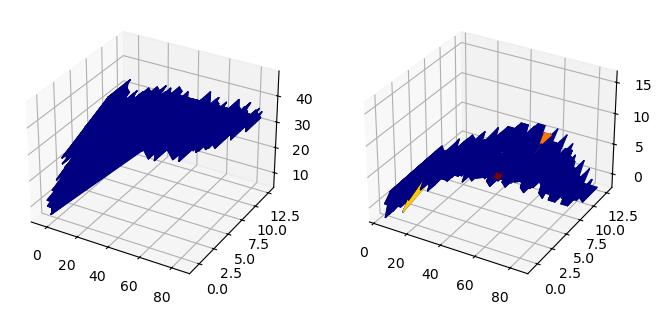

In [22]:
f = PointCloudSurface(boundaries[(0,1)])
g = PointCloudSurface(boundaries[(1,2)])
fig, axs = plt.subplots(
    1,2,
    figsize=(4*2, 4), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(f, ax=axs[0])
plot_surface(g, ax = axs[1])
plt.show()

[Iter     1] loss: 0.050037
[Iter     2] loss: 0.030591
[Iter     3] loss: 0.020986
[Iter     4] loss: 0.020984
[Iter     5] loss: 0.020984
Finished training in 5.72036s


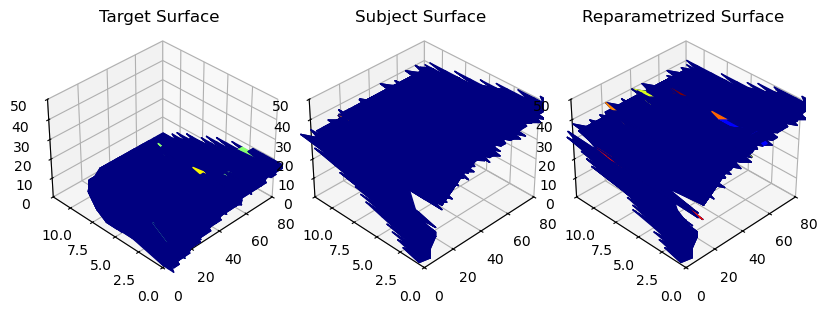

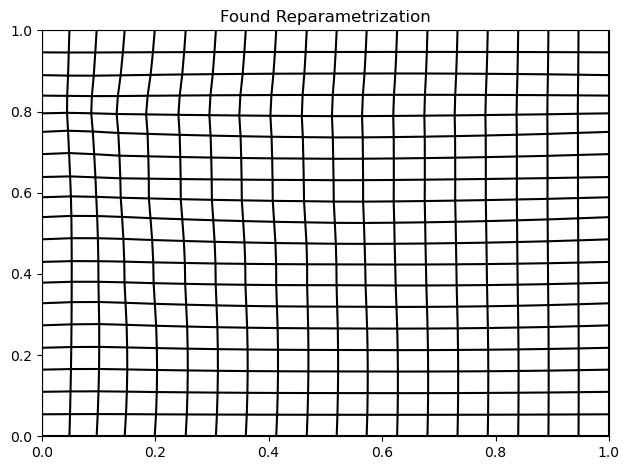

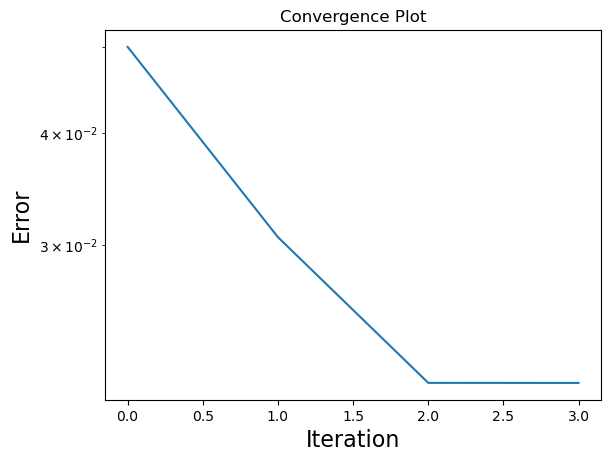

In [25]:
q = SRNF(g)
r = SRNF(f)

# Use GPU capabilities? Makes small differences for small networks,
# but is significantly more scalable.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = "cpu"

# Define reparametrization-network
RN = SurfaceReparametrizer(
    [SineFourierLayer(10) for _ in range(10)]
).to(device)
loss_func = SurfaceDistance(q, r, k=32, h=1e-4).to(device)

optimizer = optim.LBFGS(RN.parameters(), max_iter=30, line_search_fn="strong_wolfe")
errors = reparametrize(RN, loss_func, optimizer, 30, Logger(1))
RN.to("cpu"), loss_func.to("cpu"); # Need on CPU for plotting.
RN.detach()

# Reparametrize f
fafter = f.compose(RN)

# Create Coloring Functions for plotting
k = 32 # Points per dimension (k^2 points total)
camera = (35, 225)
norm = get_common_colornorm((f, g, fafter), k=k)

fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

plot_surface(g, ax=ax1, k=k, colornorm=norm, camera=camera)
ax1.set_title("Target Surface")
plot_surface(f, ax=ax2, k=k, colornorm=norm, camera=camera)
ax2.set_title("Subject Surface")
plot_surface(fafter, ax=ax3, k=k, colornorm=norm, camera=camera)
ax3.set_title("Reparametrized Surface")
for ax in [ax1, ax2, ax3]:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
plot_diffeomorphism_2d(RN, k=20, color="k", ax=ax)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Found Reparametrization")
plt.tight_layout()
plt.show()

plt.figure()
plt.semilogy(errors)
plt.axhline(0., ls="--", c="black")
plt.ylabel("Error", fontsize=16)
plt.xlabel("Iteration", fontsize=16)
plt.title("Convergence Plot")
plt.show()

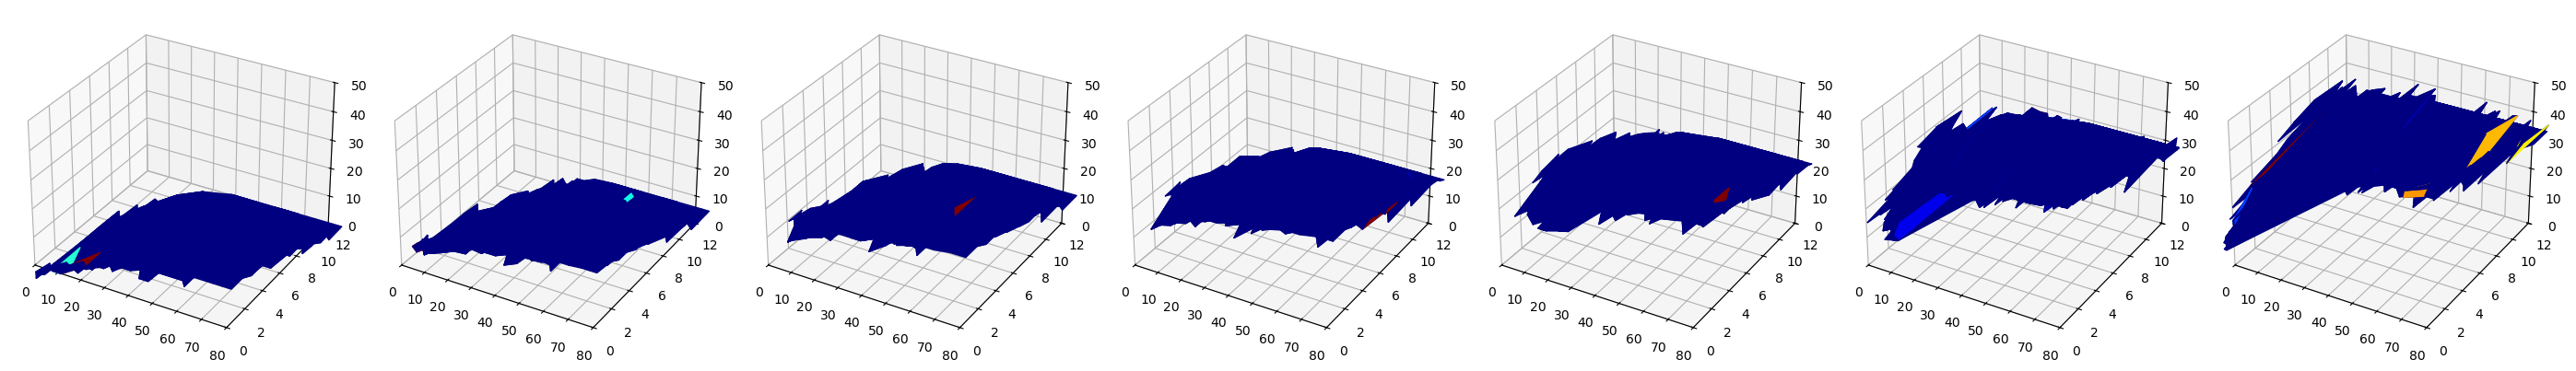

In [26]:
from funcshape.interpolation import linear_interpolate

k = 30
X, Y = torch.meshgrid((torch.linspace(0, 1, k), torch.linspace(0, 1, k)))
X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
X = torch.cat((X, Y), dim=1)
numsteps = 7
with torch.no_grad():
    fig = plt.figure(figsize=(7*4, 4))
    for i, h in enumerate(linear_interpolate(lambda x: g(RN(x)), f, numsteps)):
        ax = fig.add_subplot(1, numsteps, i+1, projection="3d")
        plot_surface(PointCloudSurface(h(X).numpy()), k=20, ax = ax)
        ax.set_xlim([0.0, 80.0])
        ax.set_ylim([0.0, 12.0])
        ax.set_zlim([0.0, 50.0])
    plt.tight_layout()
    plt.show()